<a href="https://colab.research.google.com/github/kumj2028/Math-696-Mathematical-Communication-and-Technology/blob/main/python_project1%5CProject1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Python Project 1


In this project, you will use many of the things we have learned in class so far to make a document that you might use in a (hypothetical) "professional" situation. The exact format of this document is intentionally left vague (since your interests are diverse), but there are several technical requirements and I will give an example outline (you are certainly allowed to use this, but don't have to - it's just something to give you a basic idea of the sort of thing I have in mind).

This will also tie in our readings about communicating mathematics. So you should have an explicit setting in mind when making it. For this reason, your project file will require a mix of markdown cells and code cells. In the markdown cells, you will provide exposition for the code that will appear in the cell below (e.g. "We can estimate the area under a curve with Riemann Rectangles; that is what is shown in the cell below).

In principle, it would be incredibly helpful to be able to use LaTeX (a math typsetting language) in these blocks. BUT we haven't learned that yet. (If you're wondering, I used to do LaTeX first, but was asked to change the order.) So, if you don't know LaTeX, you won't have to use it, you can just write things out in plain text (e.g. instead of $\int_{a}^{b}f(x)dx$ you can write "the integral of f from a to b").

This document should have a definite topic, so it can't just be a random assortment of things to satisfy the technical requirements.

## Technical Requirements

* You must use two packages we have used (e.g. ```sympy```, ```numpy```, ```scipy```, ```matplotlib```).
* You must write and use at least two functions.
* You must use some sort of list or array.
* You must include two plots.
* You must compare two different methods for doing the same thing (for example doing both a ```scipy``` and ```sympy``` computation. Or code your own numerical algorithm and compare with ```sympy``` or ```scipy```).

## Other Requirements
In addition to the above technical requirements, you must answer the following questions in the final cell. Your answer must be in complete sentence/paragraph form.
* Who is the audience you had in mind?
* How did that inform the way you wrote this document?
* How did the format (i.e. having to write it in Google Colab) help or hurt?
* Did you use any of the things from the readings in making this document? If so, which things were most helpful?


# Outline: Estimating $\pi$ via Cesaro's Theorem (Two RNGs)

Cesaro's theorem states that the probability that two randomly chosen positive integers are relatively prime is
\begin{equation}
\mathsf{P}(\gcd(X,Y)=1)=\frac{6}{\pi^2}.
\end{equation}
This gives a Monte Carlo estimator for $\pi$:
\begin{equation}
\hat{\pi} = \sqrt{\frac{6}{\widehat{p}}}, \quad \widehat{p}=\frac{1}{N}\sum_{i=1}^N \mathbf{1}_{\{\gcd(X_i,Y_i)=1\}}.
\end{equation}

In this notebook I estimate $\pi$ in two ways:
1) using NumPy's RNG, and
2) using the MINSTD linear congruential generator (Park-Miller, 1988).

Then I plot the estimates and errors as the number of trials increases.



In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

# Range for generated integers (strictly positive)
MAX_INT = 2147483647  # 2^31 - 1


## MINSTD (Park-Miller) RNG

We implement the "minimal standard" LCG:

- Modulus $m = 2^{31}-1 = 2147483647$
- Multiplier $ a = 7^5 = 16807 $
- Increment $ c = 0 $

The state update is $ x_{n+1} \equiv a x_n \pmod m $. We return $u_n = x_n / m \in (0,1)$.

We'll also provide helpers to sample integers in $[1, m)$.


In [2]:

class MINSTD:
    '''
    Park-Miller MINSTD RNG.
    Parameters:
        seed: int in [1, m-1]
    '''
    __slots__ = ("state",)
    a = 16807
    m = MAX_INT

    def __init__(self, seed: int = 1):
        if not (1 <= seed < self.m):
            raise ValueError("Seed must be in [1, m-1].")
        self.state = seed

    def random(self) -> float:
        # State update with modulo arithmetic
        self.state = (self.a * self.state) % self.m
        # Scale to (0, 1)
        return self.state / self.m

    def randint(self, low: int, high: int) -> int:
        '''
        Return random integer in [low, high).
        '''
        if low > high:
            raise ValueError("low must be <= high")
        u = self.random()
        return low + int(u * (high - low))

    def integers(self, low: int, high: int, size: int) -> np.ndarray:
        '''
        Generate 'size' integers in [low, high).
        '''
        return np.array([self.randint(low, high) for _ in range(size)], dtype=np.int64)


## Estimator utilities

We compute running estimates efficiently. For the NumPy RNG we can vectorize draws and use `np.gcd`.
For MINSTD we loop to produce values (then use `np.gcd` for the gcd test).

The estimator is $ \hat{\pi} = \sqrt{6 / \hat{p}} $ where $ \hat{p} $ is the proportion of coprime pairs.

In [3]:
def estimate_step_numpy(n_new: int, max_int: int, rng: np.random.Generator):
    '''
    Draw n_new pairs (X, Y) with X, Y ~ Uniform{1,...,max_int}, using NumPy RNG.
    Return number of coprime pairs among the draws.
    '''
    X = rng.integers(1, max_int + 1, size=n_new, dtype=np.int64)
    Y = rng.integers(1, max_int + 1, size=n_new, dtype=np.int64)
    return np.count_nonzero(np.gcd(X, Y) == 1)

def estimate_step_minstd(n_new: int, max_int: int, rng: MINSTD):
    '''
    Draw n_new pairs using MINSTD. Return number of coprime pairs among the draws.
    '''
    X = rng.integers(1, max_int + 1, size=n_new)
    Y = rng.integers(1, max_int + 1, size=n_new)
    return np.count_nonzero(np.gcd(X, Y) == 1)

def pi_hat_from_counts(coprime_count: int, total: int) -> float:
    '''
    Compute sqrt(6 / p_hat); guards for zero counts.
    '''
    if total == 0 or coprime_count == 0:
        return float("nan")
    p_hat = coprime_count / total
    return np.sqrt(6.0 / p_hat)

## Experiment

We increase the number of trials in steps and keep running tallies for each RNG.
Finally we plot the results.


In [4]:
# Configuration
TOTAL_TRIALS = 1_000_000
STEPS = 100
STEP_SIZES = np.diff(np.linspace(0, TOTAL_TRIALS, STEPS+1, dtype=int))

# Seeds for a reproducible run, feel free to comment out these lines
np_rng = np.random.default_rng(2025)
minstd_rng = MINSTD(seed=2025)

# Running tallies
cum_trials = 0
coprime_numpy = 0
coprime_minstd = 0

trials_axis = []
ms_diff_curve = []
np_diff_curve = []
numpy_curve = []
minstd_curve = []

t0 = time.time()
for delta in STEP_SIZES:
    # Update running totals
    cn = estimate_step_numpy(delta, MAX_INT, np_rng)
    cm = estimate_step_minstd(delta, MAX_INT, minstd_rng)
    coprime_numpy += cn
    coprime_minstd += cm
    cum_trials += delta

    # Compute estimates
    pi_np = pi_hat_from_counts(coprime_numpy, cum_trials)
    pi_ms = pi_hat_from_counts(coprime_minstd, cum_trials)

    trials_axis.append(cum_trials)
    ms_diff_curve.append(np.abs(pi_ms - np.pi))
    np_diff_curve.append(np.abs(pi_np - np.pi))
    numpy_curve.append(pi_np)
    minstd_curve.append(pi_ms)

t1 = time.time()
print(f"Completed {TOTAL_TRIALS:,} trials in {t1 - t0:.2f}s.")
print(f"Final estimates: NumPy={numpy_curve[-1]:.6f}, MINSTD={minstd_curve[-1]:.6f}, true pi={np.pi:.6f}")

Completed 1,000,000 trials in 2.37s.
Final estimates: NumPy=3.142642, MINSTD=3.140960, true pi=3.141593


<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-2782914914.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel("$\hat{\pi}_{MINSTD}$ and $\hat{\pi}_{NumPy}$")
/tmp/ipython-input-2782914914.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(trials_axis, minstd_curve, label="$\hat{\pi}_{MINSTD}$", color='blue')
/tmp/ipython-input-2782914914.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(trials_axis, numpy_curve, label="$\hat{\pi}_{NumPy}$", color='red')
/tmp/ipython-input-2782914914.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Cesaro $\pi$ Estimates (MINSTD vs NumPy)")


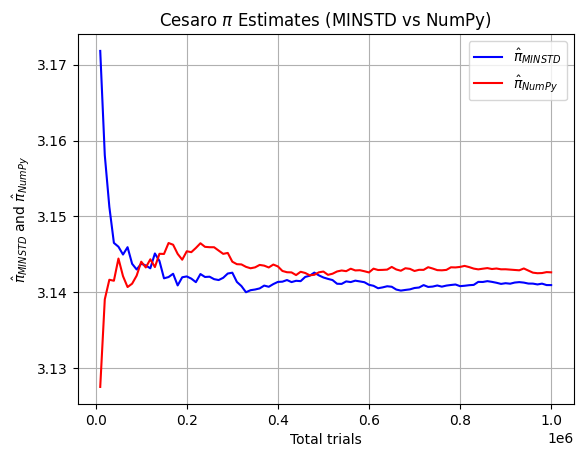

In [5]:
plt.figure()
plt.xlabel("Total trials")
plt.ylabel("$\hat{\pi}_{MINSTD}$ and $\hat{\pi}_{NumPy}$")
plt.plot(trials_axis, minstd_curve, label="$\hat{\pi}_{MINSTD}$", color='blue')
plt.plot(trials_axis, numpy_curve, label="$\hat{\pi}_{NumPy}$", color='red')
plt.legend()
plt.title("Cesaro $\pi$ Estimates (MINSTD vs NumPy)")
plt.grid(True)
plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\h'
<>:5: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-219567310.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel("absolute error in $\pi$ estimate")
/tmp/ipython-input-219567310.py:4: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(trials_axis, ms_diff_curve, label="$|\hat{\pi}_{MINSTD}$ - $\pi|$", color='blue')
/tmp/ipython-input-219567310.py:5: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(trials_axis, np_diff_curve, label="$|\hat{\pi}_{NumPy}$ - $\pi|$", color='red')
/tmp/ipython-input-219567310.py:7: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Difference in Cesaro $\pi$ Estimates (

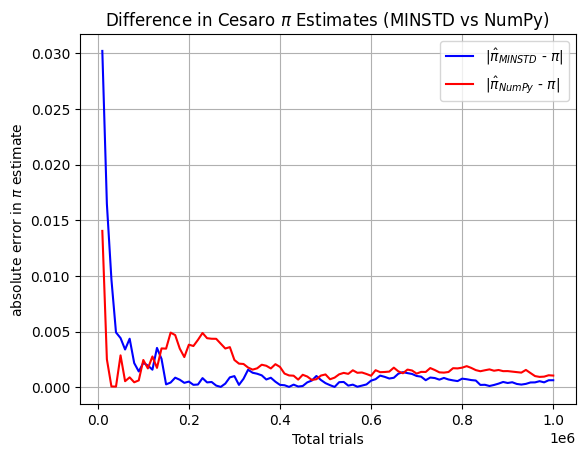

In [6]:
plt.figure()
plt.xlabel("Total trials")
plt.ylabel("absolute error in $\pi$ estimate")
plt.plot(trials_axis, ms_diff_curve, label="$|\hat{\pi}_{MINSTD}$ - $\pi|$", color='blue')
plt.plot(trials_axis, np_diff_curve, label="$|\hat{\pi}_{NumPy}$ - $\pi|$", color='red')
plt.legend()
plt.title("Difference in Cesaro $\pi$ Estimates (MINSTD vs NumPy)")
plt.grid(True)
plt.show()

### Final thoughts

**Audience**

* Probably math, statistics, or computer science  undergrads who know basic Python and a bit of number theory and probability.

**How that shaped the writing**

* Started with the theorem and the estimator in math-first markdown, then small code blocks.
* Separated concerns: RNGs (NumPy vs. MINSTD), estimation utilities, then the experiment loop, then plotting.
* Reproducibility: using seeds, as well as changeable `TOTAL_TRIALS`, `MAX_INT`, etc.

**Format (Colab) — help vs. hurt**

* **Helped:** zero-setup, cells encourage stepwise reading/execution; plots inline; learners can tweak values and instantly rerun.
* **Hurt:** Colab’s Python loops run slower than on my computer, for instance the 1,000,000 trials only took 0.73s while in Colab it took 2.37s. This limited the number of trials.

**What I used from the readings**

* I didn't really use the readings, mostly figured out things from either the online documentation, wikipedia, or stackoverflow.

